In [10]:
!pip uninstall -y scikit-learn
!pip install scikit-learn==1.5.2

Found existing installation: scikit-learn 1.6.1
Uninstalling scikit-learn-1.6.1:
  Successfully uninstalled scikit-learn-1.6.1
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 49.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
hdbscan 0.8.44 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.
umap-learn 0.5.12 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.


In [1]:
import sklearn
import tensorflow as tf
from scikeras.wrappers import KerasClassifier

print("TensorFlow:", tf.__version__)
print("Scikit-learn:", sklearn.__version__)

TensorFlow: 2.20.0
Scikit-learn: 1.5.2


Training Images Shape: (60000, 28, 28)
Training Labels Shape: (60000,)
Testing Images Shape: (10000, 28, 28)
Testing Labels Shape: (10000,)


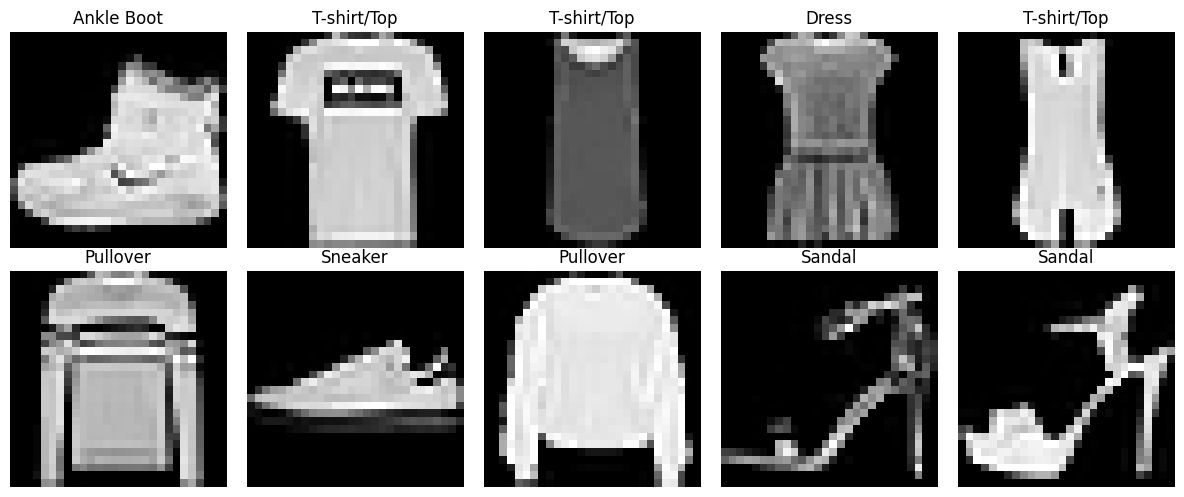

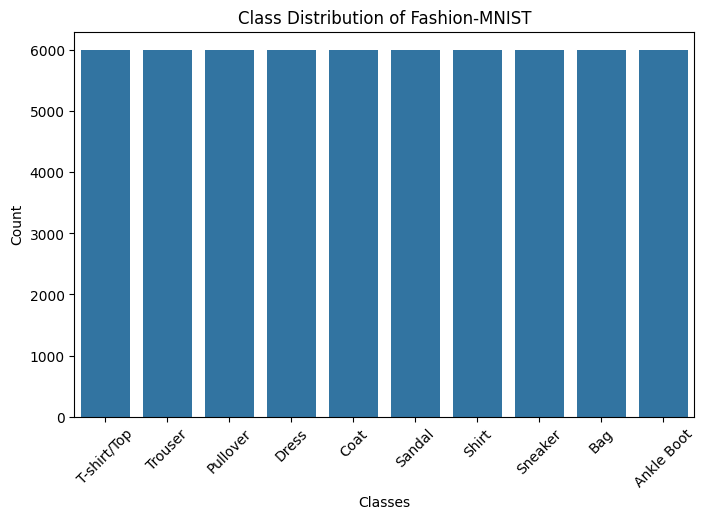

In [2]:
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.datasets import fashion_mnist

# Load Fashion-MNIST dataset
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# Print dataset dimensions
print("Training Images Shape:", X_train.shape)
print("Training Labels Shape:", y_train.shape)
print("Testing Images Shape:", X_test.shape)
print("Testing Labels Shape:", y_test.shape)

# Class names
class_names = [
    "T-shirt/Top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle Boot"
]

# Display 10 sample images
plt.figure(figsize=(12,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i], cmap='gray', interpolation='nearest')
    plt.title(class_names[y_train[i]])
    plt.axis('off')

plt.tight_layout()

# Save image
plt.savefig("Task1_Sample_Images.eps",
            format="eps",
            dpi=600,
            bbox_inches="tight")

plt.show()

# Plot class distribution
plt.figure(figsize=(8,5))
sns.countplot(x=y_train)

plt.xticks(range(10), class_names, rotation=45)
plt.xlabel("Classes")
plt.ylabel("Count")
plt.title("Class Distribution of Fashion-MNIST")

# Save image
plt.savefig("Task1_Class_Distribution.eps",
            format="eps",
            dpi=600,
            bbox_inches="tight")

plt.show()

In [3]:
from tensorflow.keras.utils import to_categorical

# Print tensor shapes before preprocessing
print("Before Preprocessing")
print("Training Images:", X_train.shape)
print("Testing Images:", X_test.shape)

# Flatten images
X_train = X_train.reshape(60000,784)
X_test = X_test.reshape(10000,784)

# Normalize pixel values
X_train = X_train.astype("float32")/255.0
X_test = X_test.astype("float32")/255.0

# One-hot encode labels
y_train_cat = to_categorical(y_train)
y_test_cat = to_categorical(y_test)

# Print tensor shapes after preprocessing
print("\nAfter Preprocessing")
print("Training Images:", X_train.shape)
print("Testing Images:", X_test.shape)
print("Training Labels:", y_train_cat.shape)
print("Testing Labels:", y_test_cat.shape)

Before Preprocessing
Training Images: (60000, 28, 28)
Testing Images: (10000, 28, 28)

After Preprocessing
Training Images: (60000, 784)
Testing Images: (10000, 784)
Training Labels: (60000, 10)
Testing Labels: (10000, 10)


In [4]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Build the MLP model
model = Sequential([
    Dense(128, activation='relu', input_shape=(784,)),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

# Display model summary
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8176 - loss: 0.5155 - val_accuracy: 0.8553 - val_loss: 0.4053
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8614 - loss: 0.3793 - val_accuracy: 0.8688 - val_loss: 0.3652
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8744 - loss: 0.3423 - val_accuracy: 0.8694 - val_loss: 0.3631
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8834 - loss: 0.3162 - val_accuracy: 0.8772 - val_loss: 0.3350
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8890 - loss: 0.2985 - val_accuracy: 0.8827 - val_loss: 0.3252
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8958 - loss: 0.2824 - val_accuracy: 0.8753 - val_loss: 0.3368
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8981 - loss: 0.2698 - val_accuracy: 0.8798 - val_loss: 0.3339
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9034 - loss: 0.2574 - 

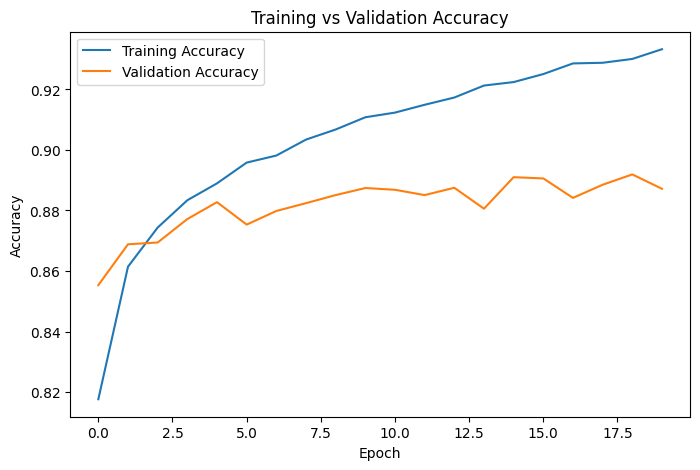

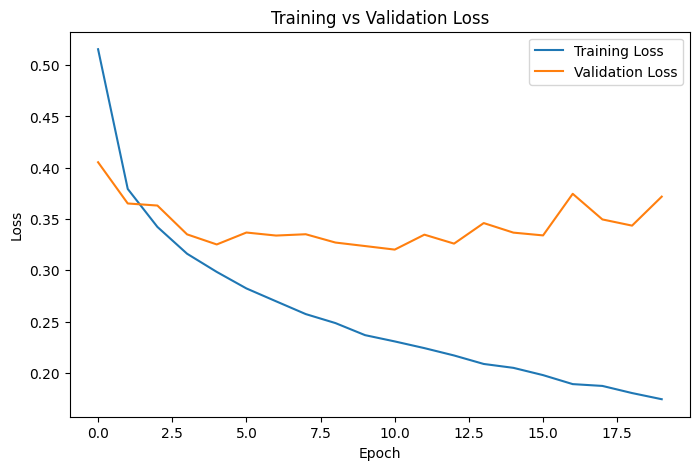

In [5]:
# Compile the model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train the model
history = model.fit(
    X_train,
    y_train_cat,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# Plot accuracy
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

# Save image
plt.savefig("Task4_Training_Validation_Accuracy.eps",
            format="eps",
            dpi=600,
            bbox_inches="tight")

plt.show()

# Plot loss
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

# Save image
plt.savefig("Task4_Training_Validation_Loss.eps",
            format="eps",
            dpi=600,
            bbox_inches="tight")

plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Accuracy : 0.8791
Precision: 0.8845215291393557
Recall   : 0.8791
F1 Score : 0.8807556794217859


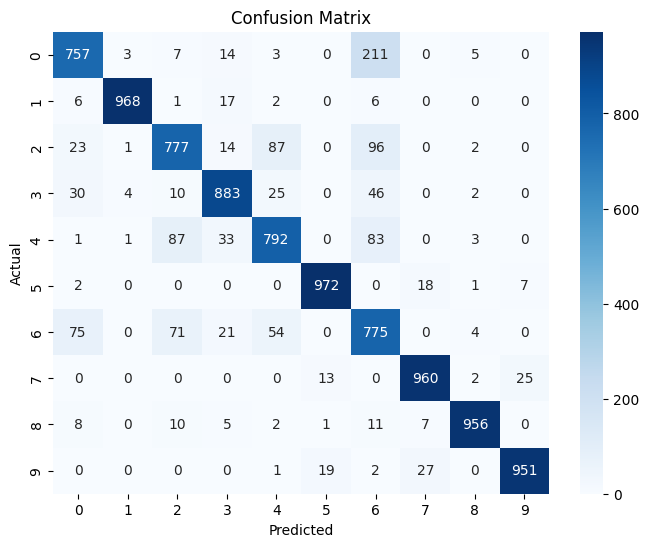

              precision    recall  f1-score   support

 T-shirt/Top       0.84      0.76      0.80      1000
     Trouser       0.99      0.97      0.98      1000
    Pullover       0.81      0.78      0.79      1000
       Dress       0.89      0.88      0.89      1000
        Coat       0.82      0.79      0.81      1000
      Sandal       0.97      0.97      0.97      1000
       Shirt       0.63      0.78      0.70      1000
     Sneaker       0.95      0.96      0.95      1000
         Bag       0.98      0.96      0.97      1000
  Ankle Boot       0.97      0.95      0.96      1000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



In [6]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

# Predict test data
y_pred_prob = model.predict(X_test)
y_pred = y_pred_prob.argmax(axis=1)

# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

# Save image
plt.savefig("Task5_Confusion_Matrix.eps",
            format="eps",
            dpi=600,
            bbox_inches="tight")

plt.show()

# Classification Report
print(classification_report(
    y_test,
    y_pred,
    target_names=class_names
))

In [10]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam, SGD, RMSprop
from tensorflow.keras.utils import to_categorical

from scikeras.wrappers import KerasClassifier
from sklearn.model_selection import RandomizedSearchCV

# One-hot encode labels
y_train_cat = to_categorical(y_train)

# Model function
def build_model(hidden_layers=2,
                neurons=128,
                learning_rate=0.001,
                optimizer="adam",
                activation="relu",
                dropout_rate=0.0):

    model = Sequential()

    model.add(Input(shape=(784,)))

    model.add(Dense(neurons, activation=activation))

    if dropout_rate > 0:
        model.add(Dropout(dropout_rate))

    for _ in range(hidden_layers - 1):
        model.add(Dense(neurons, activation=activation))

        if dropout_rate > 0:
            model.add(Dropout(dropout_rate))

    model.add(Dense(10, activation="softmax"))

    if optimizer == "adam":
        opt = Adam(learning_rate=learning_rate)
    elif optimizer == "sgd":
        opt = SGD(learning_rate=learning_rate)
    else:
        opt = RMSprop(learning_rate=learning_rate)

    model.compile(
        optimizer=opt,
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


classifier = KerasClassifier(
    model=build_model,
    verbose=0
)

# Smaller search space
param_dist = {
    "model__hidden_layers": [1, 2],
    "model__neurons": [64],
    "model__learning_rate": [0.001],
    "model__optimizer": ["adam"],
    "model__activation": ["relu"],
    "model__dropout_rate": [0.0],
    "epochs": [5],
    "batch_size": [64]
}

search = RandomizedSearchCV(
    estimator=classifier,
    param_distributions=param_dist,
    n_iter=2,
    cv=2,
    verbose=2,
    random_state=42,
    scoring="accuracy"
)

search.fit(X_train, y_train_cat)

print("Best Score:", search.best_score_)
print("Best Parameters:")
print(search.best_params_)

Fitting 2 folds for each of 2 candidates, totalling 4 fits
[CV] END batch_size=64, epochs=5, model__activation=relu, model__dropout_rate=0.0, model__hidden_layers=1, model__learning_rate=0.001, model__neurons=64, model__optimizer=adam; total time=   9.3s
[CV] END batch_size=64, epochs=5, model__activation=relu, model__dropout_rate=0.0, model__hidden_layers=1, model__learning_rate=0.001, model__neurons=64, model__optimizer=adam; total time=   9.7s
[CV] END batch_size=64, epochs=5, model__activation=relu, model__dropout_rate=0.0, model__hidden_layers=2, model__learning_rate=0.001, model__neurons=64, model__optimizer=adam; total time=  10.1s
[CV] END batch_size=64, epochs=5, model__activation=relu, model__dropout_rate=0.0, model__hidden_layers=2, model__learning_rate=0.001, model__neurons=64, model__optimizer=adam; total time=  10.6s


/usr/local/lib/python3.12/dist-packages/numpy/ma/core.py:2846: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


Best Score: 0.8671333333333333
Best Parameters:
{'model__optimizer': 'adam', 'model__neurons': 64, 'model__learning_rate': 0.001, 'model__hidden_layers': 2, 'model__dropout_rate': 0.0, 'model__activation': 'relu', 'epochs': 5, 'batch_size': 64}


In [9]:
model = build_model()

history = model.fit(
    X_train,
    y_train_cat,
    epochs=1,
    batch_size=64,
    verbose=1
)

938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8203 - loss: 0.5066
